# OCR Inference — Handwritten Letter Prediction
Full preprocessing pipeline: real photo → MNIST-style → model prediction.

---


## Step 1 — Imports

In [ ]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import models
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

print("torch       :", torch.__version__)
print("torchvision :", __import__('torchvision').__version__)
print("cv2         :", cv2.__version__)

torch       : 2.6.0+cu124
torchvision : 0.21.0+cu124
cv2         : 4.9.0
✓ Libraries loaded


## Step 2 — Model Definition

In [2]:
class OCRMobileNetV2(nn.Module):
    def __init__(self, num_classes=26, dropout_rate=0.3):
        super().__init__()
        self.backbone = models.mobilenet_v2(pretrained=False)
        for param in self.backbone.parameters():
            param.requires_grad = False
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(1280, 512),
            nn.ReLU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.backbone.features(x)
        x = nn.functional.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        return self.classifier(x)

print("✓ Model class defined")


✓ Model class defined


## Step 3 — Load Checkpoint

In [3]:
CHECKPOINT_PATH = 'ocr_mobilenetv2.pth'
CLASSES         = [chr(ord('A') + i) for i in range(26)]
DEVICE          = 'cuda' if torch.cuda.is_available() else 'cpu'

model = OCRMobileNetV2(num_classes=26, dropout_rate=0.3).to(DEVICE)
checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Loaded '{CHECKPOINT_PATH}'")
print(f"  Saved at epoch : {checkpoint['epoch']}")
print(f"  Best val acc   : {checkpoint['val_acc']*100:.4f}%")
print(f"  Device         : {DEVICE.upper()}")


c:\Users\lenovo\Desktop\OCR\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\lenovo\Desktop\OCR\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✓ Loaded 'ocr_mobilenetv2.pth'
  Saved at epoch : 15
  Best val acc   : 91.9614%
  Device         : CUDA


## Step 4 — MNIST-Style Preprocessing Pipeline

In [ ]:
def to_mnist_style(image_path: str):
    """
    Convert a real handwritten photo to MNIST-style:
      - Remove ruled lines
      - Isolate the ink stroke
      - Black background + white letter
      - Centered and padded like MNIST
    Returns both the final 28x28 numpy image and each intermediate stage.
    """
    stages = {}

    # ── 1. Load as BGR then convert to grayscale ──────────────────────────
    bgr = cv2.imread(image_path)
    if bgr is None:
        raise FileNotFoundError(f"Cannot read: {image_path}")
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    stages['1_grayscale'] = gray.copy()

    # ── 2. Remove ruled lines using morphological operations ──────────────
    # Detect horizontal lines (كشكول lines are horizontal and thin)
    horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (40, 1))
    detected_lines    = cv2.morphologyEx(gray, cv2.MORPH_OPEN,
                                         horizontal_kernel, iterations=2)
    # Subtract the lines from the image (fill with white=255)
    no_lines = cv2.add(gray, detected_lines)
    no_lines = np.clip(no_lines, 0, 255).astype(np.uint8)
    stages['2_lines_removed'] = no_lines.copy()

    # ── 3. Isolate blue/dark ink via adaptive thresholding ────────────────
    # Adaptive threshold handles uneven lighting and varying ink intensity
    thresh = cv2.adaptiveThreshold(
        no_lines, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,   # INV → ink becomes white, background black
        blockSize=31,
        C=10
    )
    stages['3_thresholded'] = thresh.copy()

    # ── 4. Denoise — remove small specks left after thresholding ──────────
    kernel      = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    denoised    = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    stages['4_denoised'] = denoised.copy()

    # ── 5. Find bounding box of the letter and crop tightly ───────────────
    coords = cv2.findNonZero(denoised)
    if coords is None:
        # Nothing detected — return blank
        stages['5_cropped'] = np.zeros((28, 28), dtype=np.uint8)
        stages['6_final_28x28'] = np.zeros((28, 28), dtype=np.uint8)
        return stages

    x, y, w, h = cv2.boundingRect(coords)
    cropped = denoised[y:y+h, x:x+w]
    stages['5_cropped'] = cropped.copy()

    # ── 6. Resize to 20x20 (MNIST leaves a 4-pixel border on each side) ──
    letter_resized = cv2.resize(cropped, (20, 20), interpolation=cv2.INTER_AREA)

    # ── 7. Pad to 28x28 with black (center the letter like MNIST) ─────────
    final = np.zeros((28, 28), dtype=np.uint8)
    final[4:24, 4:24] = letter_resized
    stages['6_final_28x28'] = final.copy()

    return stages


def preprocess(image_path: str) -> torch.Tensor:
    """Full pipeline: real photo → MNIST-style → ImageNet-normalised tensor."""
    stages = to_mnist_style(image_path)
    img_28 = stages['6_final_28x28']           # uint8 [0, 255], black bg

    # Upscale to 224x224 (what MobileNetV2 expects)
    img_224 = cv2.resize(img_28, (224, 224), interpolation=cv2.INTER_CUBIC)

    # Stack to 3 channels
    img_rgb = np.stack([img_224] * 3, axis=-1).astype(np.uint8)

    # Convert to PIL and apply ImageNet normalisation
    pil_img = Image.fromarray(img_rgb, mode='RGB')
    tensor  = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std =[0.229, 0.224, 0.225]),
    ])(pil_img).unsqueeze(0)

    return tensor, stages


print("MNIST-style preprocessing pipeline ready")


✓ MNIST-style preprocessing pipeline ready


## Step 5 — Prediction Function

In [ ]:
def predict(image_path: str):
    tensor, stages = preprocess(image_path)
    tensor = tensor.to(DEVICE)
    with torch.no_grad():
        logits = model(tensor)
        probs  = F.softmax(logits, dim=1).squeeze()
    confidence, pred_idx = probs.max(dim=0)
    return CLASSES[pred_idx.item()], confidence.item() * 100, probs.cpu().numpy(), stages

print("predict() ready")


✓ predict() ready


## Step 6 — Run Prediction

Change `IMAGE_PATH` to your image.

Working directory: c:\Users\lenovo\Desktop\OCR

  Predicted letter : M
  Confidence       : 45.67%

  Top-5 predictions:
  Rank  Letter   Confidence
  -------------------------
  1     M            45.67%
  2     Y            10.55%
  3     N             8.37%
  4     A             5.54%
  5     T             5.48%


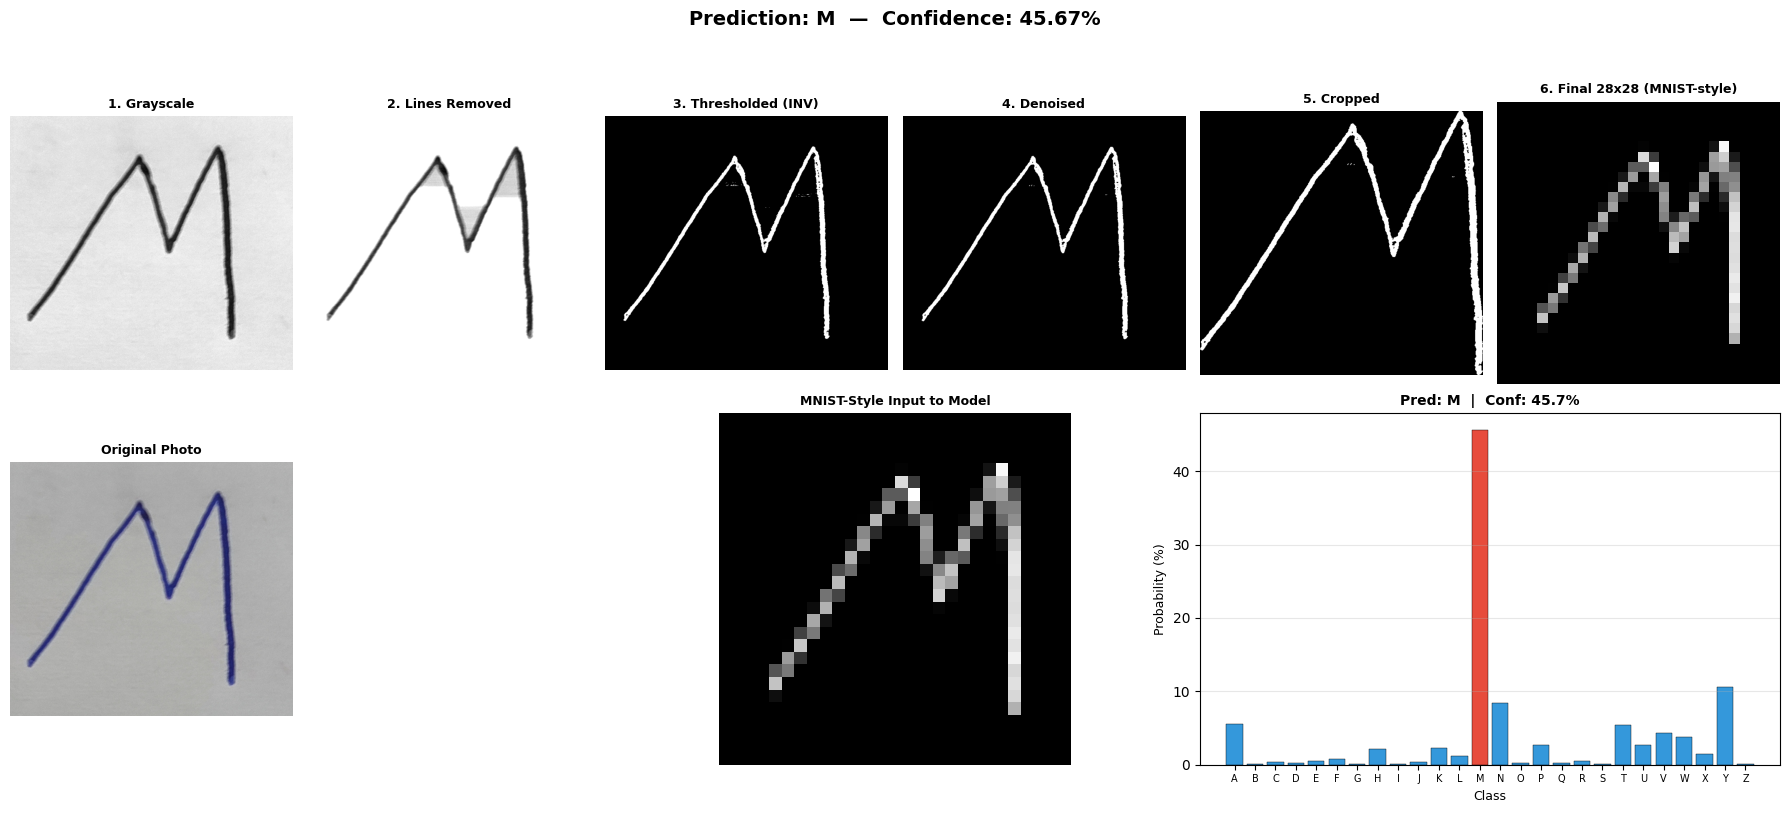


✓ prediction_result.png saved


In [ ]:
# \ SET YOUR IMAGE PATH HERE ]\
IMAGE_PATH = r'X.jpg'  


print("Working directory:", os.getcwd())

predicted_char, confidence_pct, all_probs, stages = predict(IMAGE_PATH)

print(f"\n{'='*40}")
print(f"  Predicted letter : {predicted_char}")
print(f"  Confidence       : {confidence_pct:.2f}%")
print(f"{'='*40}")

top5_idx = all_probs.argsort()[::-1][:5]
print("\n  Top-5 predictions:")
print(f"  {'Rank':<5} {'Letter':<8} {'Confidence':>10}")
print(f"  {'-'*25}")
for rank, idx in enumerate(top5_idx, 1):
    print(f"  {rank:<5} {CLASSES[idx]:<8} {all_probs[idx]*100:>9.2f}%")

# ── Visualise every preprocessing stage ─────────────────────────────────────
stage_labels = {
    '1_grayscale'    : '1. Grayscale',
    '2_lines_removed': '2. Lines Removed',
    '3_thresholded'  : '3. Thresholded (INV)',
    '4_denoised'     : '4. Denoised',
    '5_cropped'      : '5. Cropped',
    '6_final_28x28'  : '6. Final 28x28 (MNIST-style)',
}

fig = plt.figure(figsize=(18, 8))

# Row 1: preprocessing stages
for i, (key, label) in enumerate(stage_labels.items()):
    ax = fig.add_subplot(2, 6, i + 1)
    if key in stages:
        ax.imshow(stages[key], cmap='gray')
    ax.set_title(label, fontsize=9, fontweight='bold')
    ax.axis('off')

# Row 2, col 1-2: original photo
ax_orig = fig.add_subplot(2, 6, 7)
raw = cv2.imread(IMAGE_PATH)
raw_rgb = cv2.cvtColor(raw, cv2.COLOR_BGR2RGB)
ax_orig.imshow(raw_rgb)
ax_orig.set_title('Original Photo', fontsize=9, fontweight='bold')
ax_orig.axis('off')

# Row 2, col 3-4: final MNIST-style (bigger)
ax_mnist = fig.add_subplot(2, 6, (9, 10))
ax_mnist.imshow(stages['6_final_28x28'], cmap='gray')
ax_mnist.set_title(f'MNIST-Style Input to Model', fontsize=9, fontweight='bold')
ax_mnist.axis('off')

# Row 2, col 5-6: probability bar chart
ax_bar = fig.add_subplot(2, 6, (11, 12))
colors = ['#e74c3c' if CLASSES[i] == predicted_char else '#3498db' for i in range(26)]
ax_bar.bar(CLASSES, all_probs * 100, color=colors, edgecolor='black', linewidth=0.3)
ax_bar.set_xlabel('Class', fontsize=9)
ax_bar.set_ylabel('Probability (%)', fontsize=9)
ax_bar.set_title(f'Pred: {predicted_char}  |  Conf: {confidence_pct:.1f}%',
                 fontsize=10, fontweight='bold')
ax_bar.tick_params(axis='x', labelsize=7)
ax_bar.grid(axis='y', alpha=0.3)

plt.suptitle(f'Prediction: {predicted_char}  —  Confidence: {confidence_pct:.2f}%',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('prediction_result.png', dpi=130, bbox_inches='tight')
plt.show()